## Part 1 — Aggregate Loss Simulation

Combining frequency and severity into a single loss model.

S = X₁ + X₂ + ... + X_N

- N ~ Negative Binomial (from Part 2)
- X ~ Spliced Lognormal-GPD (from Part 3)

Monte Carlo simulation: repeat 50,000 times
to build the empirical annual loss distribution.

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import nbinom, genpareto
import matplotlib.pyplot as plt
import json

pd.set_option('display.float_format', '{:.3f}'.format)


In [4]:
# Load Calibrated Parameters 
with open('../data/calibrated_params.json', 'r') as f:
    params = json.load(f)

r_mle = params['r_mle']
p_mle = params['p_mle']
lambda_mle = params['lambda_mle']
alpha = params['alpha']
threshold = params['threshold']
sigma_sp = params['sigma_sp']
scale_sp = params['scale_sp']
xi_gpd = params['xi_gpd']
sigma_gpd = params['sigma_gpd']

print('Parameters loaded:')
for k, v in params.items():
    print(f'  {k}: {v:.6f}')

Parameters loaded:
  r_mle: 0.776909
  p_mle: 0.935859
  lambda_mle: 0.053247
  alpha: 0.989977
  threshold: 16793.704400
  sigma_sp: 1.066902
  scale_sp: 907.870921
  xi_gpd: 0.851939
  sigma_gpd: 17465.060319


In [5]:
# Aggregate Loss Simulation 
n_sim = 50000

aggregate_losses = []

for _ in range(n_sim):
    # frequency — Negative Binomial
    n_claims = nbinom.rvs(r_mle, p_mle)
    
    if n_claims == 0:
        aggregate_losses.append(0)
        continue
    
    # severity — Spliced Lognormal + GPD
    claims = []
    for _ in range(n_claims):
        if np.random.random() < alpha:
            s = stats.lognorm.rvs(sigma_sp, loc=0, scale=scale_sp)
            s = min(s, threshold)
        else:
            s = threshold + genpareto.rvs(xi_gpd, loc=0, scale=sigma_gpd)
        claims.append(s)
    
    aggregate_losses.append(sum(claims))

aggregate_losses = np.array(aggregate_losses)
print(f'Simulations: {n_sim}')
print(f'Mean:        {aggregate_losses.mean():.2f}')
print(f'Std:         {aggregate_losses.std():.2f}')
print(f'99.5%:       {np.percentile(aggregate_losses, 99.5):.2f}')

Simulations: 50000
Mean:        126.44
Std:         2337.80
99.5%:       4280.66


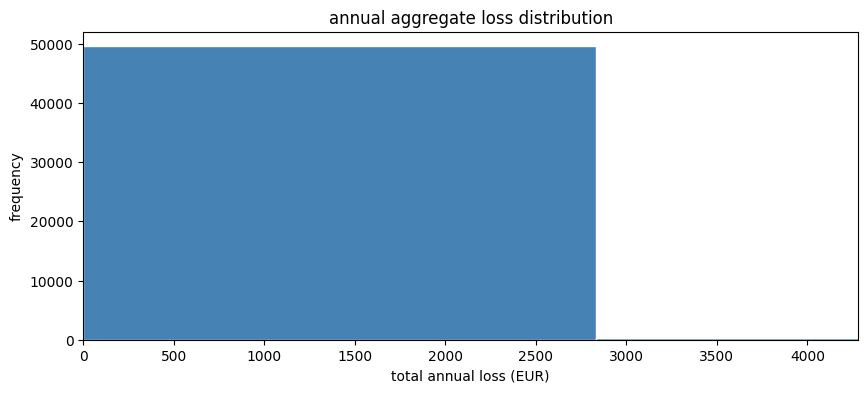

In [6]:
# --- Loss Distribution Plot ---
plt.figure(figsize=(10, 4))
plt.hist(aggregate_losses, bins=100, color='steelblue', edgecolor='white')
plt.xlim(0, np.percentile(aggregate_losses, 99.5))
plt.title('annual aggregate loss distribution')
plt.xlabel('total annual loss (EUR)')
plt.ylabel('frequency')
plt.show()

Non-zero simulations: 2543 (5.1%)


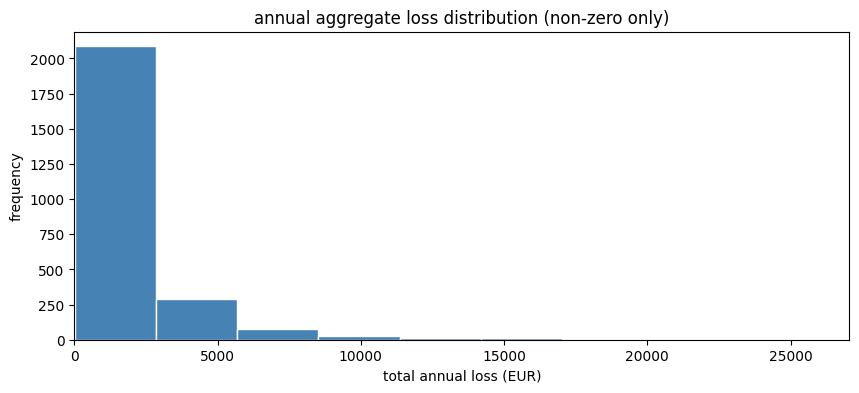

In [7]:
# --- Loss Distribution Plot (non-zero) ---
nonzero = aggregate_losses[aggregate_losses > 0]
print(f'Non-zero simulations: {len(nonzero)} ({len(nonzero)/len(aggregate_losses)*100:.1f}%)')

plt.figure(figsize=(10, 4))
plt.hist(nonzero, bins=100, color='steelblue', edgecolor='white')
plt.xlim(0, np.percentile(nonzero, 99))
plt.title('annual aggregate loss distribution (non-zero only)')
plt.xlabel('total annual loss (EUR)')
plt.ylabel('frequency')
plt.show()

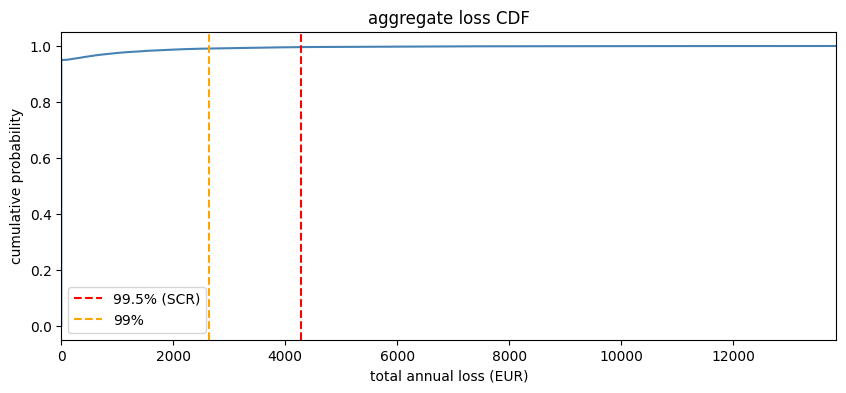

In [8]:
# --- Aggregate Loss CDF ---
sorted_losses = np.sort(aggregate_losses)
cdf = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)

plt.figure(figsize=(10, 4))
plt.plot(sorted_losses, cdf, color='steelblue', linewidth=1.5)
plt.axvline(np.percentile(aggregate_losses, 99.5), 
            color='red', linestyle='--', label='99.5% (SCR)')
plt.axvline(np.percentile(aggregate_losses, 99), 
            color='orange', linestyle='--', label='99%')
plt.xlim(0, np.percentile(aggregate_losses, 99.9))
plt.title('aggregate loss CDF')
plt.xlabel('total annual loss (EUR)')
plt.ylabel('cumulative probability')
plt.legend()
plt.show()